In [6]:
# import librairies
## data
import pandas as pd
import numpy as np

## ML (preprocessing --> transformation --> regression)
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures,StandardScaler
from sklearn.pipeline import Pipeline

## Plot
from matplotlib import pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

In [7]:
# load dataset
path="../../data/simon-data/properties-2b-located.csv"
df=pd.read_csv(path,index_col=False)
df=df.drop(['Unnamed: 0','index'],axis=1)
df.head()
df=df.drop(['Zip code','URL','City'],axis=1)
df_dum=pd.get_dummies(df,dtype=int)
print(df_dum.columns.to_numpy())
pd.set_option('display.max_columns',None)
df_dum.corr()['Price'].sort_values(ascending=False)

['Price' 'Number of rooms' 'Living Area' 'Fully equipped kitchen'
 'Furnished' 'Open fire' 'Terrace' 'Garden' 'Garden area'
 'Surface of the land' 'Number of facades' 'Swimming pool'
 'State of the building' 'Type of property_Apartment'
 'Type of property_House' 'Subtype of property_apartment'
 'Subtype of property_bungalow' 'Subtype of property_chalet'
 'Subtype of property_cottage' 'Subtype of property_duplex'
 'Subtype of property_ground-floor' 'Subtype of property_loft'
 'Subtype of property_mansion' 'Subtype of property_master-house'
 'Subtype of property_mixed-building' 'Subtype of property_penthouse'
 'Subtype of property_residence' 'Subtype of property_studio'
 'Subtype of property_triplex' 'Subtype of property_villa'
 'Type of sale_for sale' 'Type of sale_in public sale' 'Province_Antwerp'
 'Province_Brussels' 'Province_East Flanders' 'Province_Flemish Brabant'
 'Province_Hainaut' 'Province_Limburg' 'Province_Liège'
 'Province_Luxembourg' 'Province_Namur' 'Province_Walloon Bra

Price                                 1.000000
Living Area                           0.606439
Number of rooms                       0.422025
Region_Brussels                       0.251412
Province_Brussels                     0.251412
Subtype of property_villa             0.229893
Garden area                           0.181150
State of the building                 0.175256
Terrace                               0.160843
Swimming pool                         0.159765
Surface of the land                   0.156598
Open fire                             0.153500
Garden                                0.147758
Subtype of property_penthouse         0.140926
Type of property_House                0.137375
Subtype of property_master-house      0.116658
Subtype of property_mixed-building    0.107945
Number of facades                     0.098824
Province_Flemish Brabant              0.073838
Subtype of property_mansion           0.057066
Province_Walloon Brabant              0.042334
Type of sale_

In [8]:
degree=2
# —————————————————————————————————
X=df_dum.drop('Price',axis=1)
y=df['Price']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.1,random_state=11)
X_train=X_train.to_numpy()
y_train=y_train.to_numpy()
X_test=X_test.to_numpy()
y_test=y_test.to_numpy()

Input=[('polynomial',PolynomialFeatures(degree=degree)),('scale',StandardScaler()),('Model',LinearRegression())]
pipe=Pipeline(Input)
pipe.fit(X_train,y_train)
pipe.score(X_train,y_train)
y_pred=pipe.predict(X_test)
pipe.score(X_test,y_test)


0.7186870809146042

In [9]:
# ————————————————————————————————
# Characteristics to try:
## - Type of model : Linear, Polynomial, Ridge
###     - Linear : try with StdScaler
###     - Polynomial : degree (1,2 and 3)
###     - Ridge : alpha (10^-(4,3,2,1,0,-1))
## StandardScaler: Yes/No
## 2 Datasets by Type of property

def get_all_models_score(X_train,X_test,y_train,y_test):
    # ================================
    '''01 - Linear'''
    # ================================
    Input=[('scale',StandardScaler()),('Model',LinearRegression())]
    lm=LinearRegression()
    pipe_lm=Pipeline(Input)

    # Std
    pipe_lm.fit(X_train,y_train)
    lm_score_train=pipe_lm.score(X_train,y_train)
    lm_score_test=pipe_lm.score(X_test,y_test)

    # NoStd
    lm.fit(X_train,y_train)
    lm_score_nostd_train=lm.score(X_train,y_train)
    lm_score_nostd_test=lm.score(X_test,y_test)

    print(f'Linear :\ntrain_R^2={lm_score_train};test_R^2={lm_score_test}')
    print(f'No StdScaler : train_R^2={lm_score_nostd_train};test_R^2={lm_score_nostd_test}')
    print("")

    # ================================
    '''02 - Polynomial'''
    # ================================
    for scaler in ["Std Scaler:","No Std Scaler:"]:
        print(f'Polynomial - {scaler}')
        if scaler=='Std Scaler:':
            list_pol_score=[]
            for degree in range(3):
                Input=[('polynomial',PolynomialFeatures(degree=degree)),('scale',StandardScaler()),('Model',LinearRegression())]
                pipe_pol=Pipeline(Input)
                pipe_pol.fit(X_train,y_train)
                pol_score_train=pipe_pol.score(X_train,y_train)
                pol_score_test=pipe_pol.score(X_test,y_test)
                list_pol_score.append(pol_score_test)
                print(f'with degree={degree}, train_R^2={pol_score_train};test_R^2={pol_score_test}')
            print('')
        else:
            list_pol_score_nostd=[]
            for degree in range(3):
                Input=[('polynomial',PolynomialFeatures(degree=degree)),('Model',LinearRegression())]
                pol=Pipeline(Input)
                pol.fit(X_train,y_train)
                pol_score_nostd_train=pol.score(X_train,y_train)
                pol_score_nostd_test=pol.score(X_test,y_test)
                list_pol_score_nostd.append(pol_score_nostd_test)
                print(f'with degree={degree},train_R^2={pol_score_nostd_train},test_R^2={pol_score_nostd_test}')
    print('')

    # ================================
    '''03 - Ridge'''
    # ================================
    list_ridge_score_std=[]
    list_ridge_score_nostd=[]
    for scaler in ["Std Scaler:","No Std Scaler:"]:
        print(f'Ridge - {scaler}:')
        for exp in range(-5,4):
            alpha=10**exp
            if scaler=='Std Scaler:':
                Input=[('polynomial',PolynomialFeatures(degree=2)),('scale',StandardScaler()),('Model',Ridge(alpha=alpha))]
                pipe_ridge=Pipeline(Input)
                pipe_ridge.fit(X_train,y_train)
                rid_score_train=pipe_ridge.score(X_train,y_train)
                rid_score_test=pipe_ridge.score(X_test,y_test)
                list_ridge_score_std.append(rid_score_test)
                print(f'with alpha={alpha},train_R^2={rid_score_train};test_R^2={rid_score_test}')
            else:
                Input=[('polynomial',PolynomialFeatures(degree=2)),('Model',Ridge(alpha=alpha))]
                pipe_ridge=Pipeline(Input)
                pipe_ridge.fit(X_train,y_train)
                rid_score_nostd_train=pipe_ridge.score(X_train,y_train)
                rid_score_nostd_test=pipe_ridge.score(X_test,y_test)
                list_ridge_score_nostd.append(rid_score_nostd_test)
                print(f'with alpha={alpha},train_R^2={rid_score_nostd_train};test_R^2={rid_score_nostd_test}')
    # ===============================
    '''04 - Plot Scores'''
    scores_dict={'lm_score_std':lm_score_test,'lm_score_nostd':lm_score_nostd_test,'pol_score_std':max(list_pol_score),'pol_score_nostd':max(list_pol_score_nostd),"ridge_score_std":max(list_ridge_score_std),"ridge_score_nostd":max(list_ridge_score_nostd)}
    values = list(scores_dict.values())
    norm = mcolors.Normalize(vmin=min(values), vmax=max(values))
    colors = [cm.RdYlGn(norm(v)) for v in values]
    plt.bar(scores_dict.keys(), scores_dict.values(), color=colors)
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('R²')
    plt.title('Model scores comparison')
    plt.tight_layout()
    plt.show()


Linear :
train_R^2=0.5775683537753562;test_R^2=0.5785343914511416
No StdScaler : train_R^2=0.5775683537753562;test_R^2=0.5785343914511413

Polynomial - Std Scaler:
with degree=0, train_R^2=0.0;test_R^2=-0.0007678695585031647
with degree=1, train_R^2=0.5775683537753562;test_R^2=0.5785343914511416
with degree=2, train_R^2=0.7823067828305015;test_R^2=0.7186870809146042

Polynomial - No Std Scaler:
with degree=0,train_R^2=0.0,test_R^2=-0.0007678695585031647
with degree=1,train_R^2=0.5775683537753563,test_R^2=0.5785343914511379
with degree=2,train_R^2=0.7823067828305015,test_R^2=0.713477620593677

Ridge - Std Scaler::
with alpha=1e-05,train_R^2=0.7823067828305014;test_R^2=0.7186869195011559
with alpha=0.0001,train_R^2=0.7823067828304968;test_R^2=0.718687072549334
with alpha=0.001,train_R^2=0.7823067828300381;test_R^2=0.7186871566458954
with alpha=0.01,train_R^2=0.7823067827841805;test_R^2=0.718687853990529
with alpha=0.1,train_R^2=0.7823067782184367;test_R^2=0.7186947923874758
with alpha=1,

/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.0713627542334915e-20.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.201368738666642e-19.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


with alpha=0.01,train_R^2=0.7823062382775089;test_R^2=0.713545000568446
with alpha=0.1,train_R^2=0.7822875048779463;test_R^2=0.7140651923319563


/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.1042005753385003e-18.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.2131168603130484e-17.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.6367846703133479e-16.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


with alpha=1,train_R^2=0.7818977490891528;test_R^2=0.7169260910532842
with alpha=10,train_R^2=0.7793483188159115;test_R^2=0.722117953831643
with alpha=100,train_R^2=0.7742611290734216;test_R^2=0.7224089304071852
with alpha=1000,train_R^2=0.7684360219882519;test_R^2=0.7208093845034276


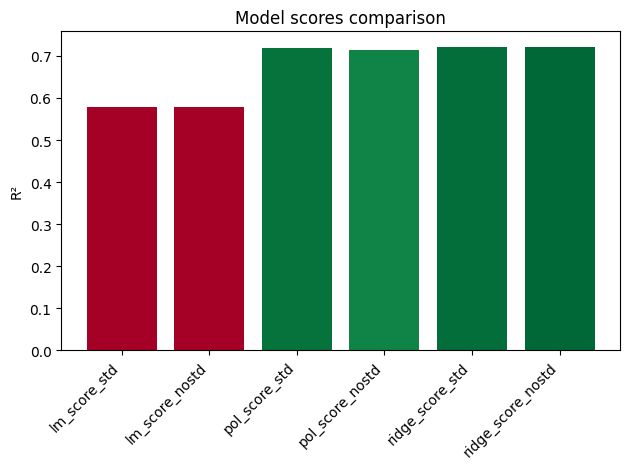

In [10]:
get_all_models_score(X_train,X_test,y_train,y_test)

In [11]:
10**5

100000

In [12]:
X_train

array([[  2., 172.,   2., ...,   1.,   0.,   0.],
       [  3., 223.,   2., ...,   1.,   0.,   0.],
       [  3., 174.,   2., ...,   0.,   1.,   0.],
       ...,
       [  2.,  97.,   2., ...,   1.,   0.,   0.],
       [  5., 190.,   2., ...,   0.,   1.,   0.],
       [  2.,  95.,   2., ...,   0.,   1.,   0.]], shape=(10631, 45))

In [13]:
a=[1,5,3]

In [14]:
max(a)

5